# Jupyter notebook

In [13]:
%load_ext autotime
%matplotlib inline

The autotime extension is already loaded. To reload it, use:
  %reload_ext autotime
time: 1.31 ms (started: 2026-05-30 08:03:24 +03:00)


## Замер времени выполнения

In [14]:
import time

start_time = time.perf_counter()

time: 523 μs (started: 2026-05-30 08:03:24 +03:00)


## Подключаем основные модули

In [15]:
import socket

import clickhouse_connect
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from my_module.my_func import (
    get_null_exists_estimation,
    highlight_values,
)


time: 649 μs (started: 2026-05-30 08:03:24 +03:00)


## Объявляем основные переменные
`local_host_name` - локальное имя хоста<br>
`docker_host_name` - docker имя хоста<br>
`sample_percent` - размер выборки в процентах<br>
`sample_count` - кол-во выборок<br>
`db` - база данных<br>
`table` - название таблицы<br>


In [32]:
local_host_name = "home-NMH-WDX9"
docker_host_name = "service.db_clickhouse"

db = "cars"
table = "car_sales"

sample_percent = 0.01
sample_count = 3

time: 300 μs (started: 2026-05-30 08:04:44 +03:00)


## Подключаемся к база данных `clickhouse`

Подключение к `ClickHouse` через официальный драйвер `clickhouse-connect`.<br>
Если запуск `.ipynb` происходит на локальной машине а не в `docker` то `host = "localhost"`.<br>
Иначе указывается адрес сурвиса в рамках docker - `"service.db_clickhouse"`.

Для корректной работы `home-NMH-WDX9` нужно заменить на имя вашей локальной машины.

In [17]:
hostname = socket.gethostname()
host = docker_host_name
if hostname == local_host_name:
    host = "localhost"

client = clickhouse_connect.get_client(
    host=host, port=8123, username="default", password=""
)

time: 20 ms (started: 2026-05-30 08:03:24 +03:00)


## Получаем общее кол-во записей в таблице `car_sales`

Получаем общее кол-во записей в таблице `car_sales`. 

На основании полученной информаци формируем размер выборки `sample_size`. <br>
Размер выборки формируется в зависимости от значения `sample_percent`, которое задается в процентах от общего кол-ва записей в таблице.

In [18]:
sql = f"SELECT COUNT(*) FROM {db}.{table};"  # noqa: S608
result = client.query(sql)
rows_count = result.result_rows[0][0]
sample_size = round(rows_count * sample_percent)
info_dict = {
    "Metric": [
        f"Кол-во записей в таблице {db}.{table}",
        f"Размер выборки ({sample_percent * 100}%)",
    ],
    "Value": [f"{rows_count:_d}", f"{sample_size:_d}"],
}
info_df = pd.DataFrame(info_dict)
info_df

,Metric,Value
0,Кол-во записей в таблице cars.car_sales,1_294_757
1,Размер выборки (1.0%),12_948


time: 15.3 ms (started: 2026-05-30 08:03:24 +03:00)


## Формирование отчета аналогичного `pandas` -  `df.info()`

In [31]:
sql = f"DESCRIBE TABLE {db}.{table}"
result = client.query_df(sql).set_index("name")

cars_columns = result.index.to_list()

field_not_null_counts = {}
for column in cars_columns:
    sql = f"""SELECT
    count(*) as non_null_count
    FROM {db}.{table}
    WHERE `{column}` IS NOT NULL;"""  # noqa: S608
    field_not_null_counts[column] = client.query(sql).result_rows[0][0]
df = pd.DataFrame.from_dict(
    field_not_null_counts, orient="index", columns=["Non-Null Count"]
)

df["Null Count"] = rows_count - df["Non-Null Count"]
df["Null Count %"] = round((df["Null Count"] * 100) / rows_count, 2)

rez = pd.concat([result, df], axis=1).reset_index().rename(columns={"index": "field"})
rez = rez[["field", "type", "Non-Null Count", "Null Count", "Null Count %"]]
rez["Null Count %"] = pd.to_numeric(rez["Null Count %"], errors="coerce")
rez["Description"] = rez.apply(lambda row : get_null_exists_estimation(row, 30), axis=1)

threshold = 30
rez_styled = rez.style.map(
    lambda val: highlight_values(val, threshold=threshold), subset=["Null Count %"]
).format({"Null Count %": "{:.2f}"})

rez_styled

,field,type,Non-Null Count,Null Count,Null Count %,Description
0,brand,Nullable(String),1294757,0,0.00,
1,name,Nullable(String),1294757,0,0.00,
2,bodyType,Nullable(String),1294757,0,0.00,
3,color,Nullable(String),1257029,37728,2.91,Мало
4,fuelType,Nullable(String),1289815,4942,0.38,Мало
5,year,Nullable(UInt32),724644,570113,44.03,Много
6,mileage,Nullable(UInt32),771799,522958,40.39,Много
7,transmission,Nullable(String),1289563,5194,0.40,Мало
8,power,Nullable(UInt16),1273353,21404,1.65,Мало
9,price,UInt32,1294757,0,0.00,


time: 160 ms (started: 2026-05-30 08:03:48 +03:00)


## Кол-во Null значений от общего кол-ва значений

In [20]:
n = rez["Null Count"].sum()
null_dict = {
    "Null Values Count": n,
    "All Values Count": rows_count * len(rez),
    "Percent (%)": (n * 100) / (rows_count * len(rez)),
}
null_dict_df = pd.DataFrame(null_dict, index=[0])
null_dict_df

,Null Values Count,All Values Count,Percent (%)
0,2923714,23305626,12.5451


time: 6.3 ms (started: 2026-05-30 08:03:24 +03:00)


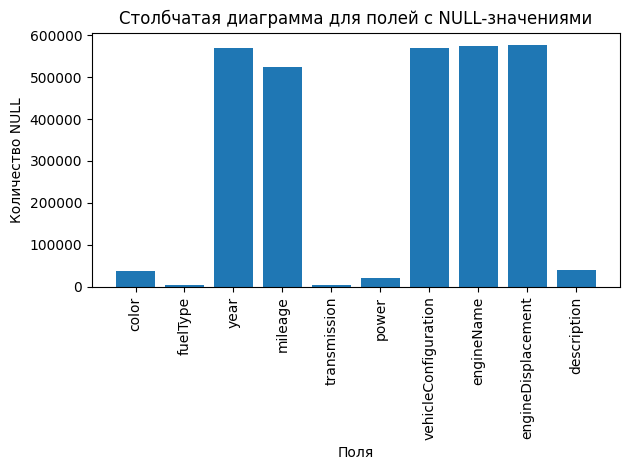

time: 134 ms (started: 2026-05-30 08:03:24 +03:00)


In [21]:
filtered_data = rez[rez["Null Count"] > 0]
plt.bar(filtered_data["field"], filtered_data["Null Count"])

plt.title("Столбчатая диаграмма для полей с NULL-значениями")
plt.xlabel("Поля")
plt.ylabel("Количество NULL")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


## Формирование отчета аналогичного `pandas` -  `df.describe()`

In [22]:
fields = ["price", "year", "mileage", "power"]
agg_funcs = {
    "count": "count",
    "mean": "avg",
    "std": "stddevPop",
    "min": "min",
    "25%": "quantile(0.25)",
    "50%": "quantile(0.50)",
    "75%": "quantile(0.75)",
    "max": "max",
}
totals = {}
for field in fields:
    totals[f"total_{field}"] = {}
    for key, func in agg_funcs.items():
        sql = f"""SELECT {func}({field}) FROM {db}.{table};"""  # noqa: S608
        result = client.query(sql)
        totals[f"total_{field}"].setdefault(key, 0)
        totals[f"total_{field}"][key] = result.result_rows[0][0]
totals_df = pd.DataFrame(totals)
with pd.option_context(
    "display.float_format",
    "{:.2f}".format,
    "display.expand_frame_repr",
    False,
):
    display(totals_df)


,total_price,total_year,total_mileage,total_power
count,1294757.00,724644.00,771799.00,1273353.00
mean,1444357.82,2009.68,154893.40,141.56
std,1970256.65,9.37,100738.27,65.64
min,270.00,1936.00,1000.00,1.00
25%,445000.00,2004.00,83000.00,98.00
50%,871200.00,2011.00,144000.00,128.00
75%,1770000.00,2017.00,211000.00,165.00
max,150000000.00,2023.00,1000000.00,1000.00


time: 422 ms (started: 2026-05-30 08:03:25 +03:00)


## Формирование нескольких выборок


In [23]:
cars_columns2 = cars_columns.copy()
cars_columns2.remove("link")
cars_columns2.remove("description")

dfs = []
sample_count = 3
sql = f"""
WITH ranked AS (
    SELECT
        {",".join(cars_columns2)},
        NTILE({sample_count}) OVER (ORDER BY rand()) AS tile
    FROM cars.car_sales
),
ranked_with_row_num AS (
    SELECT
        *,
        ROW_NUMBER() OVER (PARTITION BY tile ORDER BY rand()) AS row_num
    FROM ranked
)
SELECT *
FROM ranked_with_row_num
WHERE row_num <= {sample_size}
"""  # noqa: S608
df = client.query_df(sql)
df_renamed = df.rename(
    columns={"engineDisplacement": "ED", "vehicleConfiguration": "VC"}
)

for group_id in range(1, sample_count + 1):
    dfs.append(df_renamed[df_renamed["tile"] == group_id])  # noqa: PERF401


time: 1.88 s (started: 2026-05-30 08:03:25 +03:00)


In [24]:
dfs[0].sample(5)

,brand,name,bodyType,color,fuelType,year,mileage,transmission,power,price,VC,engineName,ED,date,location,parse_date,tile,row_num
33287,Toyota,Esquire,Минивэн,Черный,Бензин,<NA>,<NA>,Вариатор,99,1959000,<NA>,<NA>,NaN,2023-06-08,Пермь,2023-06-09 04:00:00,1,7392
37994,Toyota,Town Ace Noah,Минивэн,Белый,Дизель,1998,270000,АКПП,94,730000,2.2DT Super Extra spacious roof,3C-TE,2.2,2023-05-29,Черемхово,2023-05-30 04:00:00,1,12099
37358,Toyota,Corolla,Седан,Серый,Бензин,<NA>,293000,АКПП,105,325000,<NA>,<NA>,NaN,2023-06-02,Омск,2023-06-03 01:00:00,1,11463
29400,Skoda,Octavia,Лифтбек,Черный,Бензин,<NA>,168000,Робот,122,656600,<NA>,<NA>,NaN,2023-05-06,Нижний Новгород,2023-05-15 11:00:00,1,3505
35900,Toyota,Corona Exiv,Седан,Фиолетовый,Бензин,1991,405000,АКПП,115,140000,1.8 FE,4S-FE,1.8,2023-06-02,Тюмень,2023-06-02 12:00:00,1,10005


time: 17.3 ms (started: 2026-05-30 08:03:27 +03:00)


## Получение описательной статистики по выборкам

In [25]:
fields = ["price", "power", "year"]
descs = []
descs.append(totals_df)
for i in range(sample_count):
    desc = dfs[i][fields].describe()
    desc.columns = [f"df{i + 1}_{col}" for col in desc.columns]
    descs.append(desc)

combined_desc = pd.concat(descs, axis=1)

with pd.option_context(
    "display.float_format",
    "{:.2f}".format,
    "display.expand_frame_repr",
    False,
):
    display(combined_desc)


,total_price,total_year,total_mileage,total_power,df1_price,df1_power,df1_year,df2_price,df2_power,df2_year,df3_price,df3_power,df3_year
count,1294757.00,724644.00,771799.00,1273353.00,12948.00,12726.00,7207.00,12948.00,12732.00,7082.00,12948.00,12748.00,7238.00
mean,1444357.82,2009.68,154893.40,141.56,1462959.86,141.84,2009.38,1412221.35,140.35,2009.62,1473463.64,142.66,2009.85
std,1970256.65,9.37,100738.27,65.64,2444943.37,66.96,9.41,1876253.66,63.88,9.33,2011918.98,66.95,9.28
min,270.00,1936.00,1000.00,1.00,7000.00,3.00,1943.00,15000.00,33.00,1939.00,6000.00,33.00,1953.00
25%,445000.00,2004.00,83000.00,98.00,420000.00,98.00,2003.00,410000.00,98.00,2004.00,425000.00,99.00,2004.00
50%,871200.00,2011.00,144000.00,128.00,869000.00,125.00,2010.00,856500.00,125.00,2011.00,880000.00,128.00,2011.00
75%,1770000.00,2017.00,211000.00,165.00,1759250.00,163.00,2017.00,1720000.00,160.00,2017.00,1800000.00,165.00,2017.00
max,150000000.00,2023.00,1000000.00,1000.00,150000000.00,800.00,2023.00,35890000.00,650.00,2023.00,36999999.00,712.00,2023.00


time: 36.1 ms (started: 2026-05-30 08:03:27 +03:00)


## Сравнение описательной статистики по выборкам с общими данными на предмет наличия/отсутствия существенных расхождений

In [26]:
new_df = totals_df.copy()
rows = new_df.index.tolist()
rows.remove("min")
rows.remove("max")

fields = ["price", "power", "year"]
for field in fields:
    new_df.loc[rows, f"avg_{field}"] = (
        combined_desc.loc[rows].filter(regex=rf"df\d+_{field}").sum(axis=1)
        / sample_count
    )
    new_df[f"{field}_diff"] = new_df[f"total_{field}"] - new_df[f"avg_{field}"]
    new_df[f"{field}_diff_P"] = 100 - round(
        (new_df[f"avg_{field}"] * 100) / new_df[f"total_{field}"], 2
    )

result = new_df.filter(regex="^total_|_diff_P$")

with pd.option_context(
    "display.float_format",
    "{:.2f}".format,
    "display.expand_frame_repr",
    False,
):
    display(result)


,total_price,total_year,total_mileage,total_power,price_diff_P,power_diff_P,year_diff_P
count,1294757.00,724644.00,771799.00,1273353.00,99.00,99.00,99.01
mean,1444357.82,2009.68,154893.40,141.56,-0.36,-0.04,0.00
std,1970256.65,9.37,100738.27,65.64,-7.15,-0.45,0.28
min,270.00,1936.00,1000.00,1.00,NaN,<NA>,<NA>
25%,445000.00,2004.00,83000.00,98.00,5.99,-0.34,0.02
50%,871200.00,2011.00,144000.00,128.00,0.31,1.56,0.02
75%,1770000.00,2017.00,211000.00,165.00,0.58,1.41,0.00
max,150000000.00,2023.00,1000000.00,1000.00,NaN,<NA>,<NA>


time: 29.9 ms (started: 2026-05-30 08:03:27 +03:00)


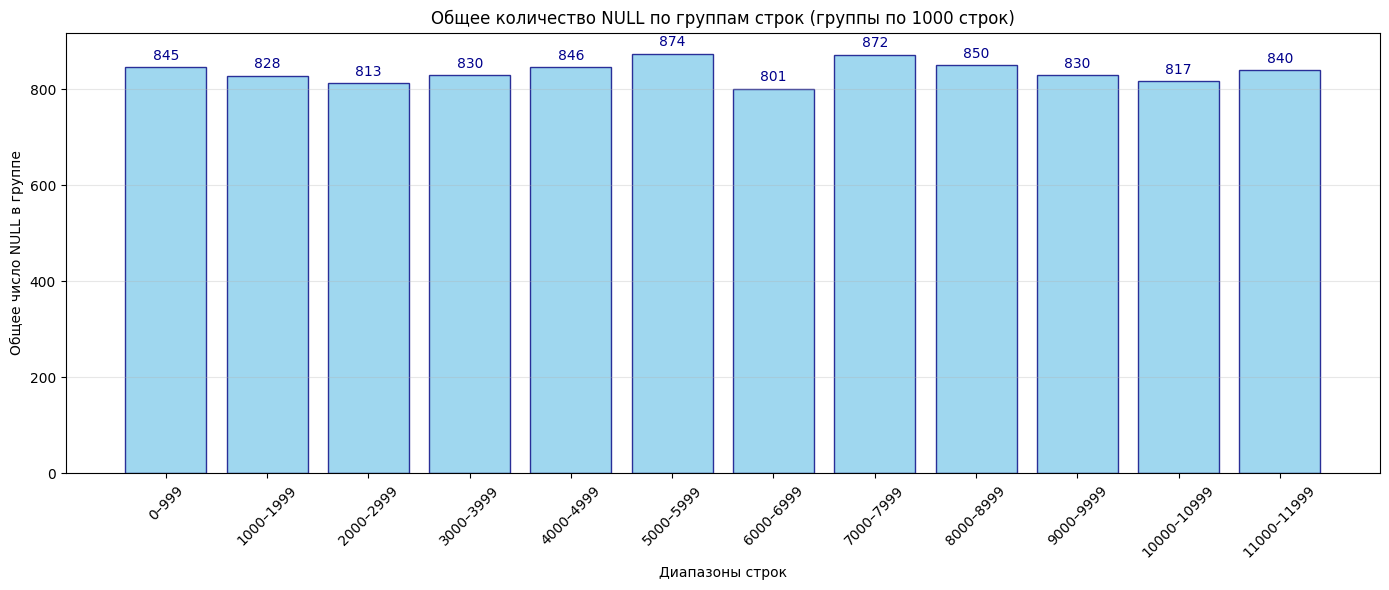

time: 205 ms (started: 2026-05-30 08:03:27 +03:00)


In [27]:
row_null_count = dfs[0][["price", "year", "mileage"]].isnull().sum(axis=1)

# Параметры группировки
group_size = 1000  # размер группы строк
n_groups = len(row_null_count) // group_size

# Агрегируем: общее количество NULL для каждой группы
aggregated_counts = []
group_labels = []

for i in range(n_groups):
    start_row = i * group_size
    end_row = start_row + group_size
    group_data = row_null_count.iloc[start_row:end_row]
    aggregated_counts.append(group_data.sum())  # Суммируем все NULL в группе
    group_labels.append(f"{start_row}–{end_row - 1}")

# Строим график
fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.bar(
    group_labels, aggregated_counts, color="skyblue", edgecolor="navy", alpha=0.8
)

# Добавляем значения на столбцы
ax.bar_label(
    bars,
    labels=[f"{int(val):,}" for val in aggregated_counts],
    label_type="edge",
    fontsize=10,
    color="darkblue",
    padding=3,
)

ax.set_title(f"Общее количество NULL по группам строк (группы по {group_size} строк)")
ax.set_xlabel("Диапазоны строк")
ax.set_ylabel("Общее число NULL в группе")
plt.xticks(rotation=45)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


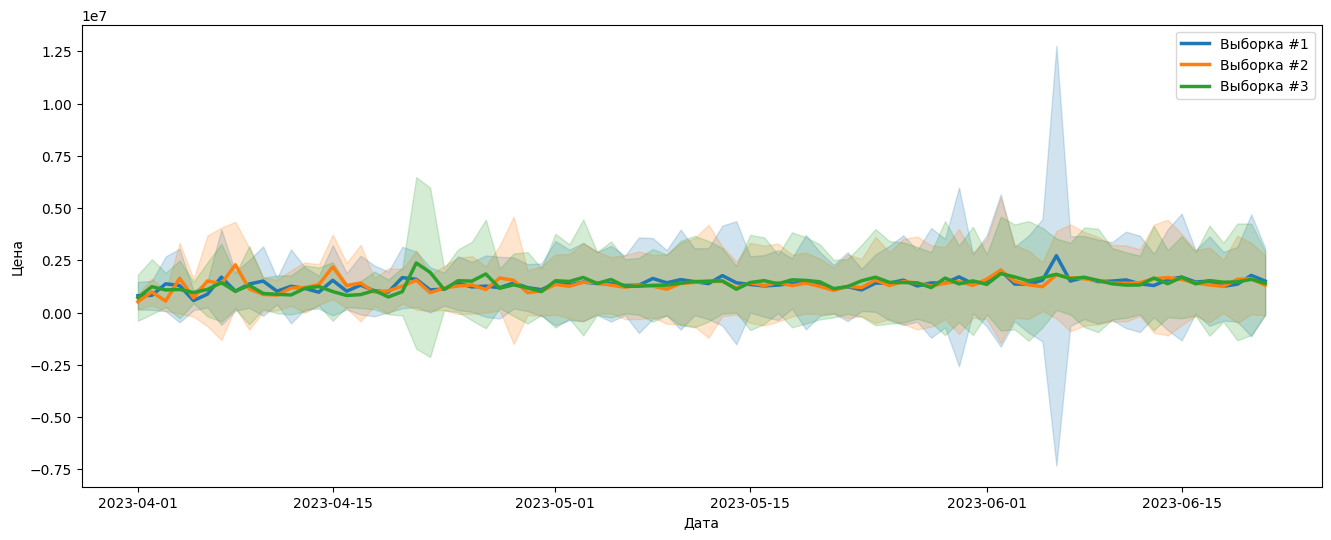

time: 301 ms (started: 2026-05-30 08:03:27 +03:00)


In [28]:
plt.figure(figsize=(16, 6))
for idx, df_number in enumerate(dfs, 1):
    sns.lineplot(
        x="date",
        y="price",
        data=df_number,
        linewidth=2.5,
        errorbar="sd",
        label=f"Выборка #{idx}",
    )
plt.xlabel("Дата")
plt.ylabel("Цена")
plt.show()

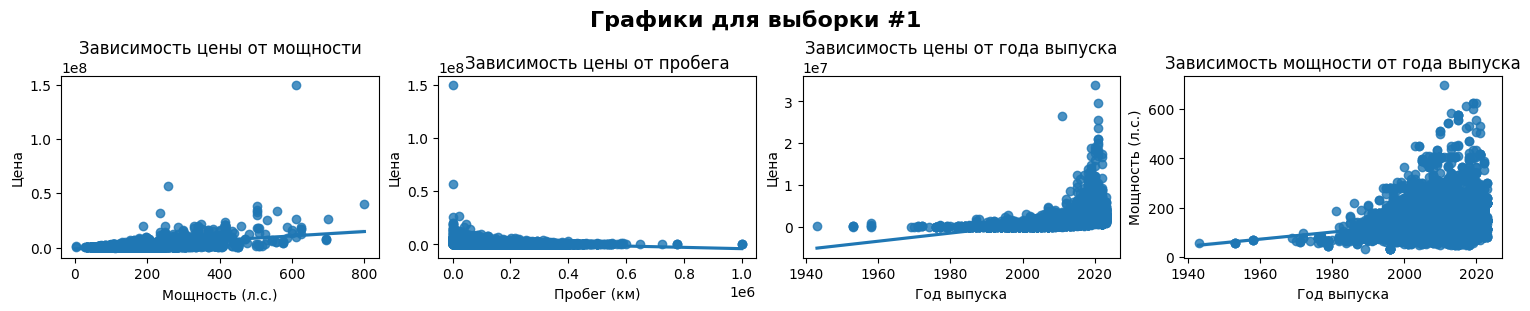

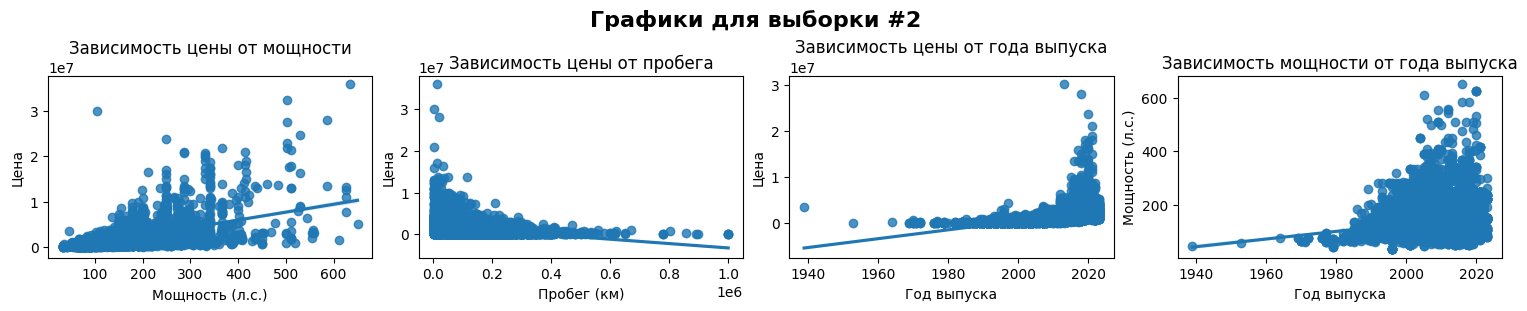

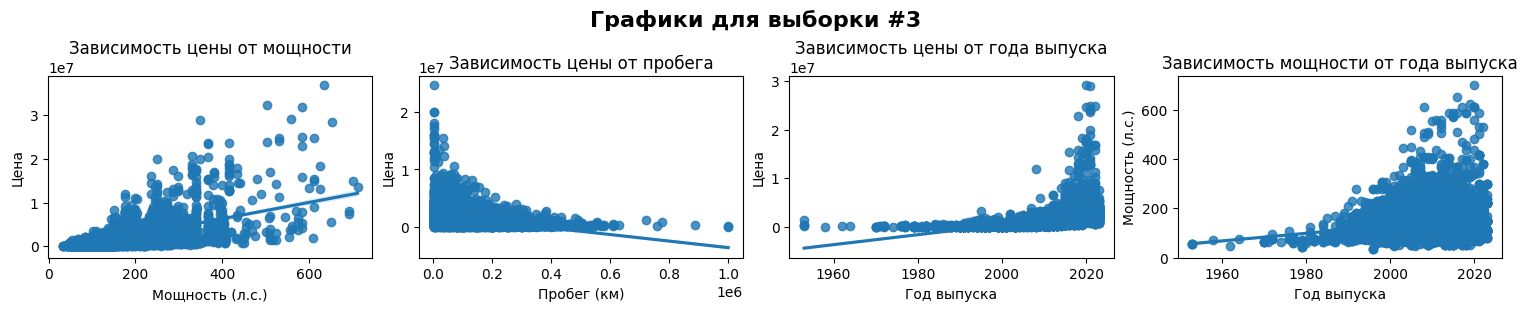

time: 5.21 s (started: 2026-05-30 08:03:28 +03:00)


In [29]:
for idx, df_number in enumerate(dfs):
    fig, axes = plt.subplots(1, 4, figsize=(15, 3), constrained_layout=True)
    fig.suptitle(f"Графики для выборки #{idx + 1}", fontsize=16, fontweight="bold")

    # График 1: power vs price
    sns.regplot(data=dfs[idx], x="power", y="price", ax=axes[0])
    axes[0].set_xlabel("Мощность (л.с.)")
    axes[0].set_ylabel("Цена")
    axes[0].set_title("Зависимость цены от мощности")

    # График 2: mileage vs price
    sns.regplot(data=dfs[idx], x="mileage", y="price", ax=axes[1])
    axes[1].set_xlabel("Пробег (км)")
    axes[1].set_ylabel("Цена")
    axes[1].set_title("Зависимость цены от пробега")

    # График 3: year vs price
    sns.regplot(data=dfs[idx], x="year", y="price", ax=axes[2])
    axes[2].set_xlabel("Год выпуска")
    axes[2].set_ylabel("Цена")
    axes[2].set_title("Зависимость цены от года выпуска")

    # График 4: year vs power
    sns.regplot(data=dfs[idx], x="year", y="power", ax=axes[3])
    axes[3].set_xlabel("Год выпуска")
    axes[3].set_ylabel("Мощность (л.с.)")
    axes[3].set_title("Зависимость мощности от года выпуска")

plt.show()


In [30]:
end_time = time.perf_counter()
total_time = end_time - start_time
print(f"Общее время выполнения: {total_time:.4f} секунд")

Общее время выполнения: 8.6394 секунд
time: 551 μs (started: 2026-05-30 08:03:33 +03:00)
